# Marker shapes for circle elements in spatialdata-plot

`render_shapes` stores circle elements as a centre point plus a radius (Visium spots, `blobs_circles`).
The `shape=` argument controls the **marker** each is drawn with — a circle, a hexagon, a square, or a
Visium-style hexagon — without changing the underlying geometry. By the end you should be able to:

- Draw circle elements as circles, hexagons, or squares with `shape=`.
- Render Visium spots as a hex grid with `shape="visium_hex"`.
- Combine `shape=` with colouring and outlines.

We use the synthetic `blobs` dataset for the basic shapes and the real 10x **Visium** mouse-brain
dataset from `squidpy` for the Visium hexagons, both cached on first use.

## Setup

In [1]:
import spatialdata as sd
import squidpy as sq

import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sd.datasets.blobs()
sdata

/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. The default — circles

The default is `shape=None`, which renders each element as its stored geometry — circles here.
Passing `shape="circle"` is equivalent for circle elements.

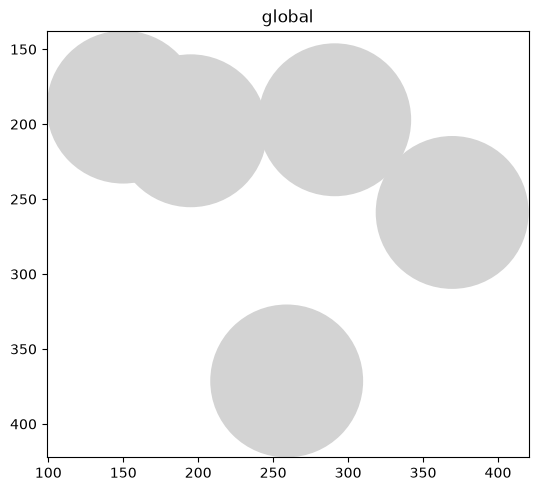

In [2]:
sdata.pl.render_shapes("blobs_circles").pl.show()

## 2. Hexagons and squares — `shape=`

`shape="hex"` and `shape="square"` redraw the same circles as hexagons or squares, sized to the
radius. Handy when a tiling look reads better than overlapping discs.

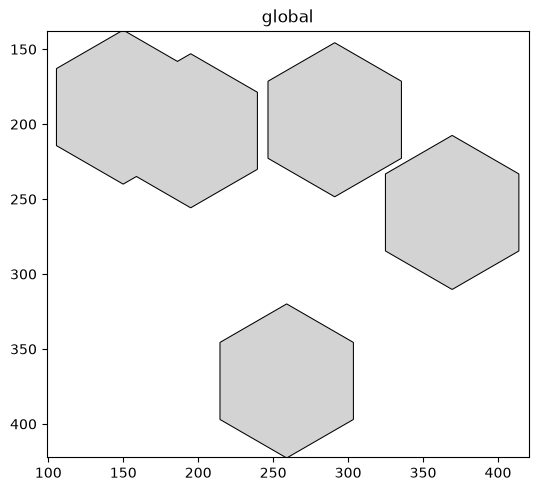

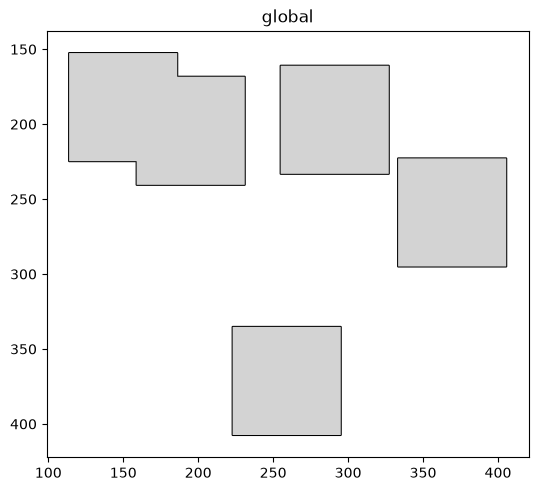

In [3]:
for shape in ["hex", "square"]:
    sdata.pl.render_shapes("blobs_circles", shape=shape, outline=True).pl.show()

## 3. Visium spots as a hex grid — `shape="visium_hex"`

Visium spots sit on a hexagonal grid, and are often drawn as touching hexagons rather than dots.
`shape="visium_hex"` does exactly that. We switch to the real Visium mouse-brain section and colour by
its brain-region clusters.

We switch datasets because the synthetic `blobs_circles` are not a real hexagonal grid. The element
name (`"spots"`) and the columns (`"cluster"`, `"total_counts"`) below are specific to this dataset —
inspect `sdata.shapes` and the annotating table's columns to find the equivalents in your own data.

INFO     Loading existing dataset from data/spatialdata/visium_hne_sdata.zarr                                      


/Users/tim.treis/Documents/GitHub/spatialdata-plot/docs/notebooks/.pixi/envs/default/lib/python3.14/site-packages/squidpy/datasets/_downloader.py:209: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  return sd.read_zarr(zarr_path)


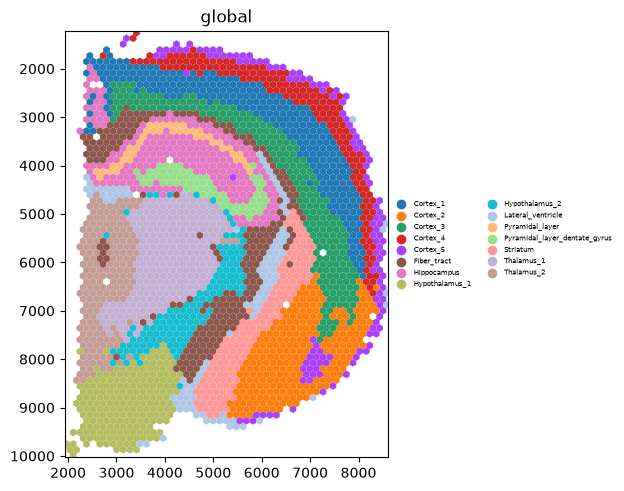

In [4]:
visium = sq.datasets.visium_hne_sdata()
visium.pl.render_shapes(
    "spots", shape="visium_hex", color="cluster"
).pl.show(legend_loc="right margin", legend_fontsize=5)

## 4. Combining `shape=` with colour and outline

`shape=` composes with the usual styling — colour by a column, add an outline, set `fill_alpha` (see
the *Styling shapes and labels* tutorial).

(See the *Legends and colorbars* example for `legend_loc` and `colorbar_params`.)

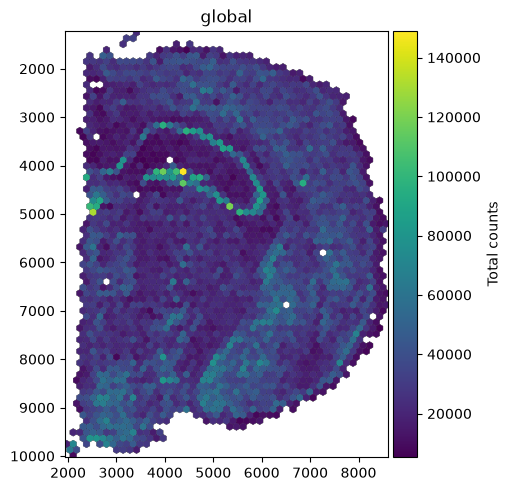

In [5]:
visium.pl.render_shapes(
    "spots", shape="visium_hex", color="total_counts",
    outline=True, outline_width=0.3, outline_color="black",
).pl.show(colorbar_params={"label": "Total counts"})

## Summary

- Circle elements (Visium spots, `blobs_circles`) carry a centre and radius; `shape=` chooses the
  marker they are drawn with, leaving the geometry unchanged.
- `shape=` accepts `None` (the default, render as-is), `"circle"`, `"hex"`, `"square"`, and
  `"visium_hex"`; this tutorial uses circle elements (centre + radius), which `shape=` is designed for.
- `shape="visium_hex"` renders Visium spots as a touching hex grid — the familiar Visium look.
- `shape=` composes with colour, outline, and the other styling arguments.

## For reproducibility

In [6]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.14.1

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.2
matplotlib      : 3.11.0
numpy           : 2.4.6

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

